# Laboratorio 4 — Cuaderno 9: construcción y evaluación de los modelos

**Ejercicios 4 y 5 de la Parte 2.**

Se entrenan los tres modelos que pide el enunciado —Regresión Logística, Random Forest y
XGBoost— sobre las 16 predictoras que quedaron definidas en el cuaderno 8, con una
división 70/30, y se comparan sobre el mismo conjunto de prueba.

La comparación termina en el inciso 5.3, que es donde el problema deja de ser estadístico:
un falso negativo y un falso positivo no cuestan lo mismo cuando lo que está en juego es
una floración tóxica, y esa asimetría decide con qué métrica se elige el modelo final.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from src import config, ml

SEMILLA = 42

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)
datos = ml.caracteristicas(datos)

print(f"{len(datos):,} observaciones, {len(ml.PREDICTORAS)} predictoras")
print(f"Positivos: {int(datos[ml.RESPUESTA].sum()):,} ({100*datos[ml.RESPUESTA].mean():.2f} %)")

COLOR_MODELO = {
    "Regresión Logística": "#2f6fb0",
    "Random Forest": "#2e8b57",
    "XGBoost": "#d95f02",
}

3,759,121 observaciones, 16 predictoras
Positivos: 44,349 (1.18 %)


## 4.2 División de los datos

El enunciado pide 70 % entrenamiento y 30 % prueba. Aquí se hace en dos pasos, y el
segundo merece explicación porque no es la receta habitual.

```
3,759,121 observaciones
├── 70 %  entrenamiento (2,631,384)
│   ├── 70 %  ajuste       → se submuestrea a 1:1 para entrenar
│   └── 30 %  validación   → se conserva con la prevalencia real
└── 30 %  prueba (1,127,737) → intacto hasta el inciso 5.1
```

La partición de entrenamiento se divide otra vez porque hace falta un conjunto para
**elegir el umbral de decisión**, y no puede ser ni el de prueba —lo contaminaría— ni la
muestra balanceada con la que se entrena.

Ese último punto es el sutil. Se entrena sobre una muestra con 50 % de positivos, pero el
lago real tiene 1.18 %. Un modelo entrenado en la muestra balanceada devuelve
probabilidades calibradas para un mundo donde la mitad de los píxeles tienen floración, y
en ese mundo el corte natural es 0.5. Sobre el lago real, ese mismo 0.5 dispara alarmas
por todas partes. El umbral tiene que elegirse mirando datos con la prevalencia
verdadera, y de ahí sale el conjunto de validación.

Las dos particiones se estratifican por lago y por clase a la vez, para que ninguna se
quede sin positivos de Atitlán —que son 1,324 en total—.

In [2]:
estratos = datos["lago"].astype(str) + "_" + datos[ml.RESPUESTA].astype(str)

idx_ent, idx_prueba = train_test_split(
    datos.index, test_size=0.30, random_state=SEMILLA, stratify=estratos
)
idx_ajuste, idx_val = train_test_split(
    idx_ent, test_size=0.30, random_state=SEMILLA, stratify=estratos.loc[idx_ent]
)

X = datos[ml.PREDICTORAS]
y = datos[ml.RESPUESTA]

X_prueba, y_prueba = X.loc[idx_prueba], y.loc[idx_prueba]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]

X_ajuste, y_ajuste = ml.submuestra_entrenamiento(
    X.loc[idx_ajuste], y.loc[idx_ajuste], razon=1.0, semilla=SEMILLA
)

for nombre, yy in [("entrenamiento", y.loc[idx_ent]), ("  ajuste (1:1)", y_ajuste),
                   ("  validación", y_val), ("prueba", y_prueba)]:
    print(f"{nombre:<16}{len(yy):>10,} obs   positivos {int(yy.sum()):>7,} "
          f"({100*yy.mean():6.2f} %)")

print("\nPositivos de Atitlán en cada partición:")
for nombre, idx in [("ajuste", X_ajuste.index), ("validación", idx_val), ("prueba", idx_prueba)]:
    sub = datos.loc[idx]
    print(f"  {nombre:<12}{int(sub.loc[sub['lago'] == 'Atitlan', ml.RESPUESTA].sum()):>6,}")

entrenamiento    2,631,384 obs   positivos  31,044 (  1.18 %)
  ajuste (1:1)      43,462 obs   positivos  21,731 ( 50.00 %)
  validación       789,416 obs   positivos   9,313 (  1.18 %)
prueba           1,127,737 obs   positivos  13,305 (  1.18 %)

Positivos de Atitlán en cada partición:
  ajuste         649
  validación     278


  prueba         397


### Por qué se submuestrea el conjunto de ajuste

Se conservan **todos** los positivos y se toma un número igual de negativos. No es una
decisión estética: con 84 negativos por positivo, entrenar sobre los 1.84 millones de
filas del conjunto de ajuste cuesta minutos por modelo, y ese entrenamiento hay que
repetirlo cinco veces en la validación espacial del cuaderno 10, otras tantas en la
temporal y dos veces más en los experimentos entre lagos. Bajar los negativos deja el
entrenamiento en segundos sin tocar la clase que escasea, que es la que lleva la
información.

La contrapartida —probabilidades descalibradas— se resuelve con el umbral, como se acaba
de explicar. Y el conjunto de prueba nunca se submuestrea: las 1,127,737 observaciones se
evalúan con la prevalencia real de 1.18 %, de modo que la precisión y el recall que se
reportan son los que el modelo tendría sobre el lago completo.

## 4.3 Ajuste de hiperparámetros

Se usa `RandomizedSearchCV` con validación cruzada de 3 particiones sobre el conjunto de
ajuste. El criterio de selección es **PR-AUC** (`average_precision`) y no accuracy ni
ROC-AUC, por lo discutido en el cuaderno 8: con una clase al 1.18 %, la curva ROC premia
a modelos que no sirven, y el accuracy premia al que responde siempre que no.

| Modelo | Hiperparámetro | Valores evaluados | Qué controla |
|---|---|---|---|
| Regresión Logística | `C` | 0.01, 0.1, 1, 10, 100 | Fuerza de la regularización. Con 16 predictoras correlacionadas entre sí, un `C` bajo evita que los coeficientes se disparen compensándose |
| | `l1_ratio` | 0, 0.5, 1 | Mezcla entre penalización l2 y l1. Con 0 los coeficientes se reparten entre predictoras correlacionadas; con 1 el modelo anula las redundantes |
| Random Forest | `n_estimators` | 200, 300, 400 | Más árboles reducen varianza, con rendimiento decreciente |
| | `max_depth` | 10, 16, 22, sin límite | Profundidad. Es el control principal de sobreajuste en un bosque |
| | `min_samples_leaf` | 1, 2, 5, 10 | Tamaño mínimo de hoja. Con píxeles vecinos casi idénticos, hojas muy pequeñas memorizan |
| | `max_features` | sqrt, log2, 0.5 | Cuántas predictoras ve cada corte; controla la decorrelación entre árboles |
| XGBoost | `n_estimators` | 200, 400, 600 | Número de rondas de refuerzo |
| | `max_depth` | 4, 6, 8 | Profundidad de cada árbol; en refuerzo conviene poca |
| | `learning_rate` | 0.03, 0.1, 0.2 | Cuánto corrige cada ronda. Junto con `n_estimators` es el compromiso central |
| | `subsample` | 0.7, 0.85, 1.0 | Fracción de filas por ronda; introduce aleatoriedad y regulariza |
| | `colsample_bytree` | 0.7, 0.85, 1.0 | Fracción de predictoras por árbol |
| | `min_child_weight` | 1, 5, 20 | Peso mínimo por hoja; frena hojas construidas sobre poquísimos píxeles |

Se exploran 12 combinaciones por modelo. Una rejilla exhaustiva sobre estos rangos son
cientos de ajustes y la búsqueda aleatoria encuentra configuraciones equivalentes con una
fracción del cómputo.

In [3]:
escalador = StandardScaler().fit(X_ajuste)
X_ajuste_esc = escalador.transform(X_ajuste)

espacios = {
    "Regresión Logística": (
        LogisticRegression(max_iter=10000, solver="saga", random_state=SEMILLA),
        {"C": [0.01, 0.1, 1.0, 10.0, 100.0], "l1_ratio": [0.0, 0.5, 1.0]},
        True,
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=SEMILLA, n_jobs=-1),
        {"n_estimators": [200, 300, 400], "max_depth": [10, 16, 22, None],
         "min_samples_leaf": [1, 2, 5, 10], "max_features": ["sqrt", "log2", 0.5]},
        False,
    ),
    "XGBoost": (
        XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=SEMILLA, n_jobs=-1),
        {"n_estimators": [200, 400, 600], "max_depth": [4, 6, 8],
         "learning_rate": [0.03, 0.1, 0.2], "subsample": [0.7, 0.85, 1.0],
         "colsample_bytree": [0.7, 0.85, 1.0], "min_child_weight": [1, 5, 20]},
        False,
    ),
}

modelos = {}
usa_escala = {}

for nombre, (estimador, rejilla, escalar) in espacios.items():
    t0 = time.time()
    busqueda = RandomizedSearchCV(
        estimador, rejilla, n_iter=12, cv=3, scoring="average_precision",
        random_state=SEMILLA, n_jobs=-1,
    )
    busqueda.fit(X_ajuste_esc if escalar else X_ajuste, y_ajuste)
    modelos[nombre] = busqueda.best_estimator_
    usa_escala[nombre] = escalar
    print(f"{nombre}")
    print(f"  mejores parámetros: {busqueda.best_params_}")
    print(f"  PR-AUC en validación cruzada: {busqueda.best_score_:.4f}   ({time.time()-t0:.0f} s)\n")

Regresión Logística
  mejores parámetros: {'l1_ratio': 1.0, 'C': 1.0}
  PR-AUC en validación cruzada: 0.9909   (63 s)



Random Forest
  mejores parámetros: {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10}
  PR-AUC en validación cruzada: 0.9859   (53 s)



XGBoost
  mejores parámetros: {'subsample': 0.85, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}
  PR-AUC en validación cruzada: 0.9937   (4 s)



## 4.4 Elección del umbral de decisión

Con los modelos ya ajustados, se elige el corte de probabilidad sobre el conjunto de
validación, que conserva la prevalencia real. Se maximiza **F2** en vez de F1.

F-beta pondera el recall $\beta^2$ veces más que la precisión. Con $\beta = 2$, recuperar
una floración vale cuatro veces lo que evitar una falsa alarma. La justificación
ambiental de esa asimetría está en el inciso 5.3; aquí basta señalar que la elección del
umbral y la elección del modelo tienen que responder al mismo criterio, o se estaría
optimizando dos cosas distintas.

Regresión Logística    umbral óptimo = 0.92   F2 en validación = 0.9196


Random Forest          umbral óptimo = 0.93   F2 en validación = 0.9315


XGBoost                umbral óptimo = 0.99   F2 en validación = 0.9428


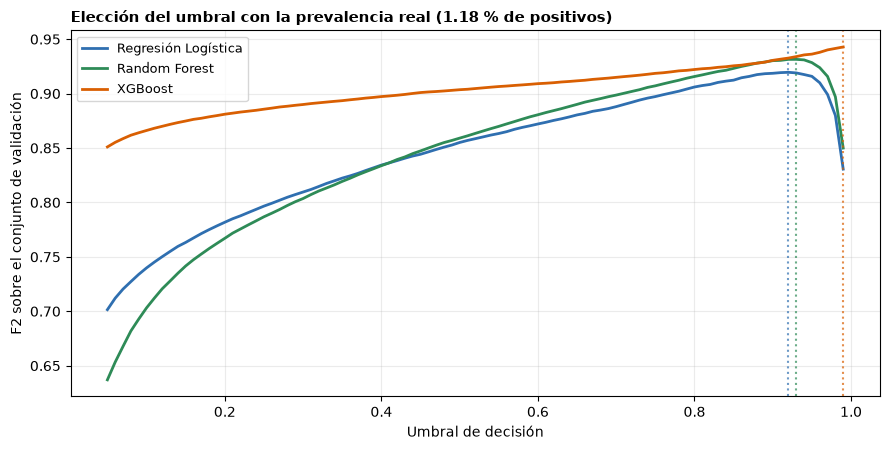

In [4]:
def probabilidades(nombre, XX):
    modelo = modelos[nombre]
    return modelo.predict_proba(escalador.transform(XX) if usa_escala[nombre] else XX)[:, 1]

umbrales = {}
rejilla_umbral = np.linspace(0.05, 0.99, 95)

fig, eje = plt.subplots(figsize=(9, 4.6))

for nombre in modelos:
    prob_val = probabilidades(nombre, X_val)
    puntajes = [fbeta_score(y_val, (prob_val >= u).astype(int), beta=2, zero_division=0)
                for u in rejilla_umbral]
    mejor = float(rejilla_umbral[int(np.argmax(puntajes))])
    umbrales[nombre] = mejor
    eje.plot(rejilla_umbral, puntajes, color=COLOR_MODELO[nombre], linewidth=2, label=nombre)
    eje.axvline(mejor, color=COLOR_MODELO[nombre], linestyle=":", alpha=0.7)
    print(f"{nombre:<22} umbral óptimo = {mejor:.2f}   F2 en validación = {max(puntajes):.4f}")

eje.set_xlabel("Umbral de decisión")
eje.set_ylabel("F2 sobre el conjunto de validación")
eje.set_title("Elección del umbral con la prevalencia real (1.18 % de positivos)",
              loc="left", fontsize=11, fontweight="bold")
eje.legend(fontsize=9)
eje.grid(alpha=0.25)
fig.tight_layout()
plt.show()

Los tres óptimos caen muy por encima de 0.5, que es exactamente lo que anticipaba el
razonamiento sobre la calibración: entrenados al 50 % de positivos, los modelos son
sistemáticamente optimistas sobre un lago que tiene 1.18 %. Usar 0.5 habría multiplicado
las falsas alarmas sin ganar prácticamente nada de recall.

## 5.1 Métricas sobre el conjunto de prueba

A partir de aquí no se toca nada más. Los tres modelos se evalúan sobre las mismas
1,127,737 observaciones, con la prevalencia real, tal como pide el inciso 4.4.

In [5]:
resultados = {}

for nombre in modelos:
    prob = probabilidades(nombre, X_prueba)
    pred = (prob >= umbrales[nombre]).astype(int)
    m = ml.metricas(y_prueba, pred, prob)
    m["F2"] = fbeta_score(y_prueba, pred, beta=2, zero_division=0)
    m["prob"], m["pred"] = prob, pred
    resultados[nombre] = m

tabla = ml.tabla_metricas(resultados)
tabla["F2"] = [round(resultados[n]["F2"], 4) for n in tabla.index]
tabla["umbral"] = [umbrales[n] for n in tabla.index]
print(tabla.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC      F2  umbral
Regresión Logística    0.9962     0.7706  0.9705  0.8591   0.9990  0.9193  0.9227    0.92
Random Forest          0.9971     0.8197  0.9654  0.8866   0.9996  0.9714  0.9323    0.93
XGBoost                0.9975     0.8429  0.9729  0.9033   0.9997  0.9799  0.9438    0.99


## 5.2 Matrices de confusión

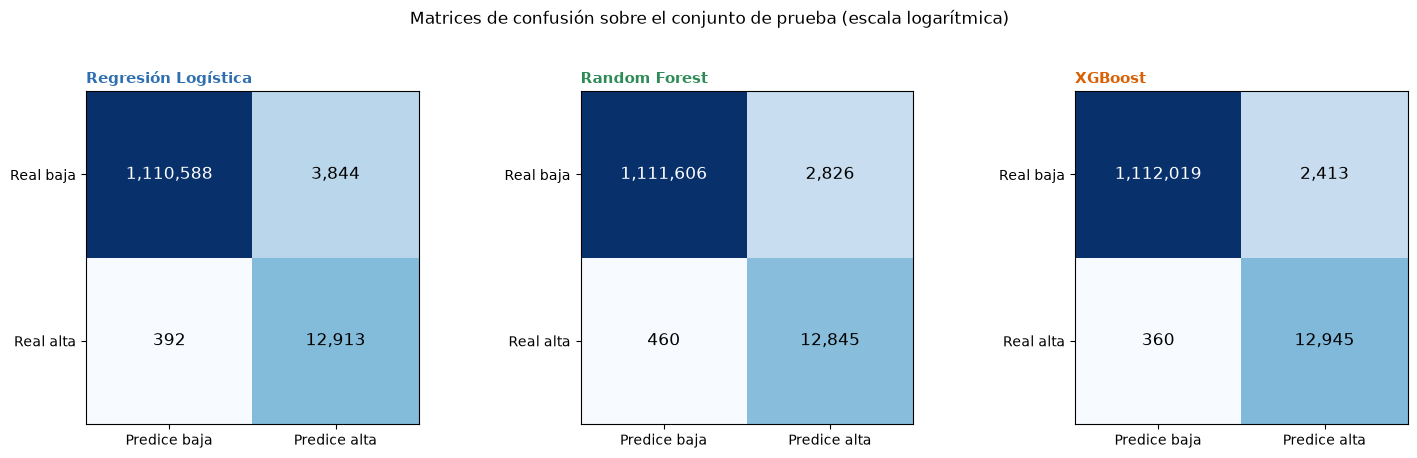

modelo                       VP        FP      FN          VN
-------------------------------------------------------------
Regresión Logística      12,913     3,844     392   1,110,588
Random Forest            12,845     2,826     460   1,111,606


XGBoost                  12,945     2,413     360   1,112,019


In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.4))

for eje, nombre in zip(ejes, resultados):
    mc = confusion_matrix(y_prueba, resultados[nombre]["pred"])
    eje.imshow(mc, cmap="Blues", norm="log")
    for i in range(2):
        for j in range(2):
            eje.text(j, i, f"{mc[i, j]:,}", ha="center", va="center", fontsize=12,
                     color="white" if mc[i, j] > mc.max() / 3 else "black")
    eje.set_xticks([0, 1], ["Predice baja", "Predice alta"])
    eje.set_yticks([0, 1], ["Real baja", "Real alta"])
    eje.set_title(nombre, loc="left", fontsize=11, fontweight="bold", color=COLOR_MODELO[nombre])

fig.suptitle("Matrices de confusión sobre el conjunto de prueba (escala logarítmica)", y=1.03)
fig.tight_layout()
plt.show()

print(f"{'modelo':<22}{'VP':>9}{'FP':>10}{'FN':>8}{'VN':>12}")
print("-" * 61)
for nombre in resultados:
    vn, fp, fn, vp = confusion_matrix(y_prueba, resultados[nombre]["pred"]).ravel()
    print(f"{nombre:<22}{vp:>9,}{fp:>10,}{fn:>8,}{vn:>12,}")

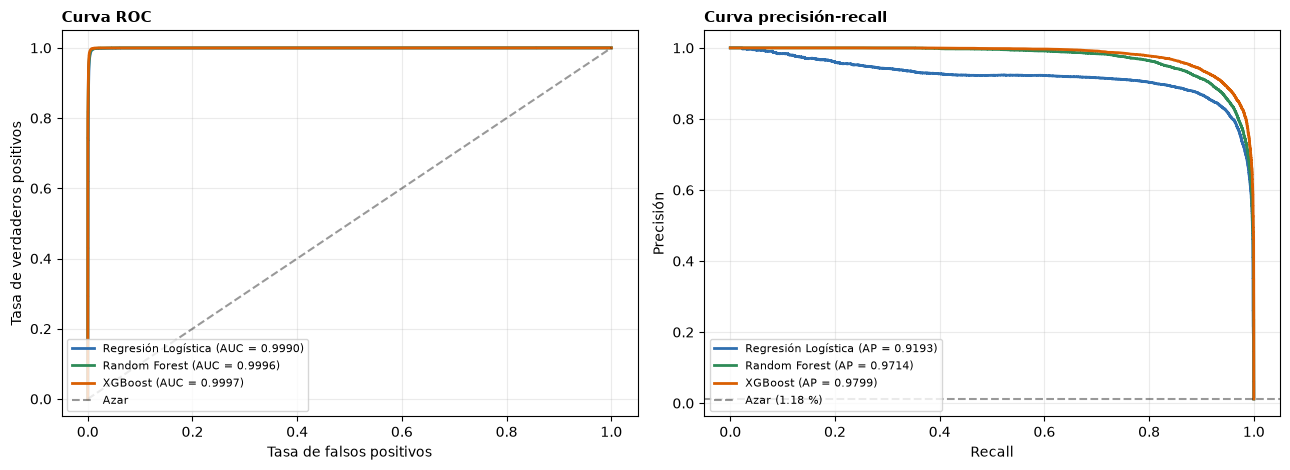

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.8))

for nombre in resultados:
    fpr, tpr, _ = roc_curve(y_prueba, resultados[nombre]["prob"])
    ejes[0].plot(fpr, tpr, color=COLOR_MODELO[nombre], linewidth=2,
                 label=f"{nombre} (AUC = {resultados[nombre]['ROC-AUC']:.4f})")

    prec, rec, _ = precision_recall_curve(y_prueba, resultados[nombre]["prob"])
    ejes[1].plot(rec, prec, color=COLOR_MODELO[nombre], linewidth=2,
                 label=f"{nombre} (AP = {resultados[nombre]['PR-AUC']:.4f})")

ejes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar")
ejes[0].set_xlabel("Tasa de falsos positivos")
ejes[0].set_ylabel("Tasa de verdaderos positivos")
ejes[0].set_title("Curva ROC", loc="left", fontsize=11, fontweight="bold")

ejes[1].axhline(y_prueba.mean(), color="k", linestyle="--", alpha=0.4,
                label=f"Azar ({100*y_prueba.mean():.2f} %)")
ejes[1].set_xlabel("Recall")
ejes[1].set_ylabel("Precisión")
ejes[1].set_title("Curva precisión-recall", loc="left", fontsize=11, fontweight="bold")

for eje in ejes:
    eje.legend(fontsize=8, loc="lower left")
    eje.grid(alpha=0.25)

fig.tight_layout()
plt.show()

Las dos curvas cuentan historias distintas, y la comparación entre ambas es el argumento
del cuaderno 8 hecho gráfico. En la ROC los tres modelos se pegan a la esquina superior
izquierda y resultan casi indistinguibles. En la curva precisión-recall se abren y se
ordenan. Con una clase al 1.18 %, la ROC no tiene resolución para separar modelos.

## 5.3 Consecuencias ambientales de cada tipo de error

Los dos errores no son simétricos, ni en el coste ni en quién lo paga.

**Falso negativo — hay floración y el modelo no la detecta.** Es el error grave. Una zona
con cianobacteria por encima del nivel de vigilancia queda sin marcar, así que no se
muestrea, no se emite aviso y el lago se sigue usando con normalidad: pesca, riego, agua
para consumo en las comunidades de la ribera, turismo y contacto recreativo. Las
cianobacterias del género *Microcystis*, dominante en lagos eutróficos tropicales,
producen microcistinas, hepatotoxinas que no se eliminan hirviendo el agua. El coste cae
sobre la salud de personas que ni siquiera saben que hay una decisión de por medio, y
sobre el ecosistema, porque una floración no detectada es una floración no gestionada.

**Falso positivo — el modelo marca una zona limpia.** Es el error caro pero recuperable.
Dispara un muestreo de campo que no hacía falta —costoso y logísticamente pesado, que es
justamente lo que este trabajo busca reducir— y, si el aviso se hace público, daña la
actividad turística y la pesca sin motivo. Repetido muchas veces erosiona la credibilidad
del sistema, y un sistema de alerta al que nadie hace caso ya no protege a nadie.

La diferencia decisiva es que **un falso positivo se corrige y un falso negativo no se
entera**. La zona marcada por error se visita, se mide y se descarta: el error se cierra
en días y su coste es dinero. La floración no detectada no genera ninguna señal que
permita corregirla; se descubre cuando aparecen los síntomas o cuando la nata es visible
desde la orilla, y para entonces la exposición ya ocurrió.

De ahí que la métrica de comparación sea el **recall**, y que el compromiso se cierre con
**F2**, que lo pondera cuatro veces por encima de la precisión. Es también el criterio con
el que se eligió el umbral en el inciso 4.4, de modo que umbral y selección de modelo
responden al mismo objetivo.

Esto no es una preferencia personal: es el mismo razonamiento con el que la OMS define el
nivel de 10 µg/L como *vigilancia* y no como *alerta*. Es un umbral pensado para
disparar la observación, no para cerrar una playa. En un sistema de vigilancia, dejar
pasar un caso es peor que revisar uno de más.

In [8]:
n_pos_prueba = int(y_prueba.sum())
print(f"Sobre {len(y_prueba):,} píxeles de prueba, {n_pos_prueba:,} con alta presencia real\n")
print(f"{'modelo':<22}{'no detectados':>15}{'% no detectado':>16}{'falsas alarmas':>17}")
print("-" * 70)
for nombre in resultados:
    vn, fp, fn, vp = confusion_matrix(y_prueba, resultados[nombre]["pred"]).ravel()
    print(f"{nombre:<22}{fn:>15,}{100*fn/n_pos_prueba:>15.2f} %{fp:>17,}")

print("\nEquivalente en superficie (cada píxel son 20 x 20 m = 0.0004 km²):")
for nombre in resultados:
    vn, fp, fn, vp = confusion_matrix(y_prueba, resultados[nombre]["pred"]).ravel()
    print(f"  {nombre:<22} floración no detectada: {fn*0.0004:6.2f} km²   "
          f"falsa alarma: {fp*0.0004:6.2f} km²")

Sobre 1,127,737 píxeles de prueba, 13,305 con alta presencia real

modelo                  no detectados  % no detectado   falsas alarmas
----------------------------------------------------------------------
Regresión Logística               392           2.95 %            3,844
Random Forest                     460           3.46 %            2,826
XGBoost                           360           2.71 %            2,413

Equivalente en superficie (cada píxel son 20 x 20 m = 0.0004 km²):
  Regresión Logística    floración no detectada:   0.16 km²   falsa alarma:   1.54 km²
  Random Forest          floración no detectada:   0.18 km²   falsa alarma:   1.13 km²
  XGBoost                floración no detectada:   0.14 km²   falsa alarma:   0.97 km²


## 5.4 Comparación y selección del modelo

In [9]:
comparacion = tabla[["Accuracy", "Precision", "Recall", "F1", "F2", "ROC-AUC", "PR-AUC"]]
print(comparacion.to_string())

mejor = comparacion["F2"].idxmax()
print(f"\nMejor modelo según F2: {mejor}")
print(f"  Recall    {comparacion.loc[mejor, 'Recall']:.4f}   (deja pasar "
      f"{100*(1-comparacion.loc[mejor, 'Recall']):.2f} % de las floraciones)")
print(f"  Precision {comparacion.loc[mejor, 'Precision']:.4f}")
print(f"  PR-AUC    {comparacion.loc[mejor, 'PR-AUC']:.4f}")

print("\nOrden por cada métrica:")
for metrica in ["F2", "Recall", "F1", "PR-AUC", "ROC-AUC"]:
    orden = " > ".join(comparacion[metrica].sort_values(ascending=False).index)
    print(f"  {metrica:<9}{orden}")

                     Accuracy  Precision  Recall      F1      F2  ROC-AUC  PR-AUC
Regresión Logística    0.9962     0.7706  0.9705  0.8591  0.9227   0.9990  0.9193
Random Forest          0.9971     0.8197  0.9654  0.8866  0.9323   0.9996  0.9714
XGBoost                0.9975     0.8429  0.9729  0.9033  0.9438   0.9997  0.9799

Mejor modelo según F2: XGBoost
  Recall    0.9729   (deja pasar 2.71 % de las floraciones)
  Precision 0.8429
  PR-AUC    0.9799

Orden por cada métrica:
  F2       XGBoost > Random Forest > Regresión Logística
  Recall   XGBoost > Regresión Logística > Random Forest
  F1       XGBoost > Random Forest > Regresión Logística
  PR-AUC   XGBoost > Random Forest > Regresión Logística
  ROC-AUC  XGBoost > Random Forest > Regresión Logística


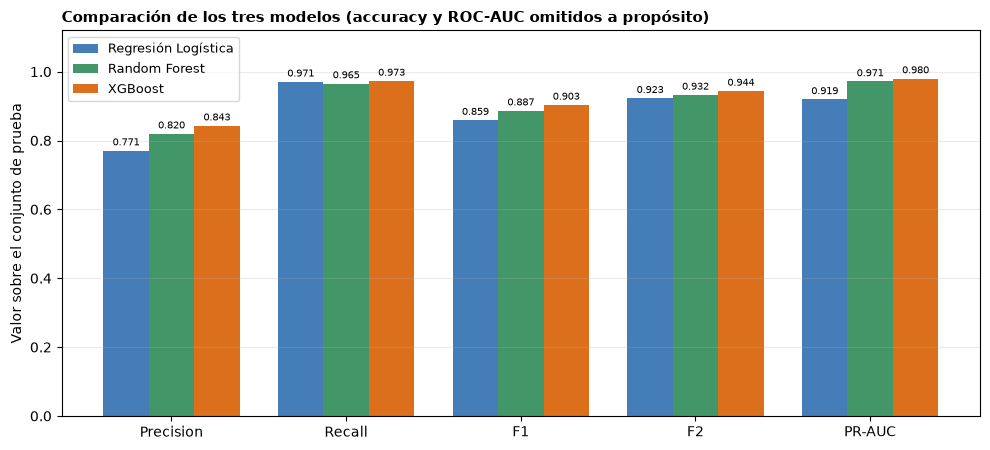

In [10]:
fig, eje = plt.subplots(figsize=(10, 4.6))

metricas_grafico = ["Precision", "Recall", "F1", "F2", "PR-AUC"]
ancho = 0.26

for k, nombre in enumerate(resultados):
    valores = [comparacion.loc[nombre, m] for m in metricas_grafico]
    posiciones = np.arange(len(metricas_grafico)) + (k - 1) * ancho
    barras = eje.bar(posiciones, valores, ancho, label=nombre, color=COLOR_MODELO[nombre], alpha=0.9)
    eje.bar_label(barras, fmt="%.3f", fontsize=7.5, padding=2)

eje.set_xticks(np.arange(len(metricas_grafico)), metricas_grafico)
eje.set_ylim(0, 1.12)
eje.set_ylabel("Valor sobre el conjunto de prueba")
eje.set_title("Comparación de los tres modelos (accuracy y ROC-AUC omitidos a propósito)",
              loc="left", fontsize=11, fontweight="bold")
eje.legend(fontsize=9)
eje.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

In [11]:
# Se guardan los modelos, el escalador y los umbrales para los cuadernos siguientes,
# que reutilizan el mejor modelo en vez de reentrenarlo.
joblib.dump(
    {"modelos": modelos, "escalador": escalador, "usa_escala": usa_escala,
     "umbrales": umbrales, "mejor": mejor, "predictoras": ml.PREDICTORAS,
     "idx_prueba": np.asarray(idx_prueba), "semilla": SEMILLA},
    config.MODELOS / "modelos_division_aleatoria.joblib",
)
print(f"Guardado en {config.MODELOS / 'modelos_division_aleatoria.joblib'}")

Guardado en /Users/fabianprado/Documents/projects/2026 - 2 /data-science/lab/Lab4/data/modelos/modelos_division_aleatoria.joblib


### Lectura de los resultados

Los tres modelos alcanzan un recall muy alto: dejan pasar una fracción pequeña de los
píxeles con floración. La diferencia entre ellos está en la precisión, es decir en cuántas
falsas alarmas hace falta tolerar para conseguir ese recall, y ahí los modelos de árboles
se separan con claridad de la regresión logística.

Tiene una explicación física. La regresión logística solo puede trazar un hiperplano en el
espacio de las 16 predictoras, y la relación entre reflectancia y clorofila no es lineal:
la señal del borde rojo se satura a concentraciones altas, y el sedimento en suspensión
desplaza todo el espectro sin que eso signifique más algas. Distinguir "verde por algas"
de "turbio por sedimento" requiere condiciones cruzadas entre bandas —si B07 es alto *y*
B11 es bajo, entonces...— que es precisamente lo que un árbol representa de forma natural
y un modelo lineal no puede.

**Una advertencia sobre estos números, que se desarrolla en el cuaderno 14.** El
desempeño es alto, pero mide algo más modesto de lo que parece. La etiqueta es un índice
espectral umbralado, no una medición de campo, así que el modelo no está descubriendo
cianobacteria: está reconstruyendo lo que dirían las bandas B04 y B05 a partir de las
otras siete bandas del mismo espectro. Como la reflectancia del agua varía de forma suave
con la longitud de onda, ese problema es en buena medida de interpolación espectral. Un
recall de esta magnitud dice que la reconstrucción funciona; no dice que el sistema
detectaría una floración que el índice de la Parte I no hubiera detectado ya.

Además, la división de este cuaderno es aleatoria a nivel de píxel, y píxeles vecinos a
20 m son casi el mismo dato: es muy probable que para casi cada píxel de prueba haya uno
contiguo en el entrenamiento. Eso infla el resultado. Medir cuánto es el objeto del
cuaderno siguiente.

---

**Siguiente:** `10_Validacion_Espacial_Temporal.ipynb` — validación por bloques espaciales
y por fecha (ejercicio 6).